# Multi-Panel Forecast Error Growth by Altitude Range

RMSE vs lead time, shown in separate panels for three altitude ranges (lower / middle / upper stratosphere) to reveal the vertical dependence of forecast skill.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [8]:
DATA_PATH      = '/home/fabio/work/HM_and_AI_models/VAE_Model/data/long_run_310k.npy'
EMU_MODEL_PATH = '/home/fabio/work/HM_and_AI_models/VAE_Model/data/best_weights/checkpoint_11'
SAVE_DIR       = os.path.dirname(os.path.abspath('__file__'))

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

LENGTH_SCALE   = 2.5e5
TIME_SCALE     = 24 * 3600.0
VELOCITY_SCALE = LENGTH_SCALE / TIME_SCALE

NZ = 26
VERTICAL_LEVELS = np.linspace(0, 70e3, NZ + 1)[1:-1] / 1000

UPPER_BOUND = 53.8 / VELOCITY_SCALE
LOWER_BOUND = 1.75 / VELOCITY_SCALE

LATENT_DIM    = 32
OUTPUT_DIM    = 75
CONDITION_DIM = 50
NUM_NEURONS   = 1024

NUM_FORECAST_DAYS = 1000
NUM_ENSEMBLE      = 50
NUM_ICS_FORE      = 10

ALT_RANGES = [
    ('Lower strat.\n(~3-22 km)',  slice(0, 8)),
    ('Middle strat.\n(~24-46 km)', slice(8, 17)),
    ('Upper strat.\n(~48-67 km)', slice(17, 25)),
]

SHOW_CLIM_DATA = False
SHOW_CLIM_HM   = False
SHOW_CLIM_EMU  = False
CLIM_RUN_STEPS = 5000

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(OUTPUT_DIM, NUM_NEURONS)
        self.fc2 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc3 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc4 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc5 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc6 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc_mu     = nn.Linear(NUM_NEURONS, LATENT_DIM)
        self.fc_logvar = nn.Linear(NUM_NEURONS, LATENT_DIM)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM + CONDITION_DIM, NUM_NEURONS)
        self.fc2 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc3 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc4 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc5 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc6 = nn.Linear(NUM_NEURONS, NUM_NEURONS)
        self.fc_output = nn.Linear(NUM_NEURONS, OUTPUT_DIM)

    def forward(self, z, cond):
        x = torch.cat((z, cond), dim=1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        return self.fc_output(x)

class ConditionalVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def decode(self, z, cond):
        return self.decoder(z, cond)

    def forward(self, x, cond):
        mu, logvar = self.encoder(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z, cond), mu, logvar

In [10]:
print("Loading data...")
real_data = np.load(DATA_PATH)
psi       = real_data[:, 1, :]
N         = len(psi)

mean_psi = np.mean(psi, axis=0)
std_psi  = np.std(psi, axis=0)

zonal_wind_ref = psi[:, 63]
U_climatology  = mean_psi[50:75] * VELOCITY_SCALE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae    = ConditionalVAE().to(device)
vae.load_state_dict(torch.load(EMU_MODEL_PATH, map_location=device, weights_only=True))
vae.eval()
print(f"Emulator loaded (device: {device})")

Loading data...
Emulator loaded (device: cuda)


In [11]:
def run_iterative_forecast(initial_cond_50, num_days, num_ensemble):
    """Iteratively forecast using VAE; returns (num_days, num_ensemble, 75) normalised."""
    predictions  = np.zeros((num_days, num_ensemble, OUTPUT_DIM))
    current_cond = initial_cond_50.clone()

    for day in range(num_days):
        with torch.no_grad():
            z        = torch.randn(num_ensemble, LATENT_DIM, device=device)
            cond_exp = current_cond.expand(num_ensemble, -1).to(device)
            y        = vae.decode(z.float(), cond_exp.float()).cpu().numpy()
        predictions[day] = y
        mean_pred    = np.mean(y, axis=0, keepdims=True)
        current_cond = torch.tensor(mean_pred[:, :CONDITION_DIM]).float()

    return predictions

In [12]:
# Climatological baselines (optional)
U_all_data = psi[:, 50:75] * VELOCITY_SCALE
clim_rmse = {}

if SHOW_CLIM_DATA:
    clim_rmse['HM Climatological Mean'] = {}
    for name, sl in ALT_RANGES:
        clim_rmse['HM Climatological Mean'][name] = np.sqrt(2 * np.mean(np.var(U_all_data[:, sl], axis=0)))

if SHOW_CLIM_HM:
    from holton_mass import HoltonMassModel
    print("Computing HM long-run climatology ...")
    hm_model = HoltonMassModel(HoltonMassModel.default_config())
    t_save = np.array([0.0, 1.0])
    state = psi[0].copy()
    U_hm_traj = np.zeros((CLIM_RUN_STEPS, 25))
    for k in range(CLIM_RUN_STEPS):
        x = hm_model.integrate_euler_maruyama(state[np.newaxis], t_save, seed=None)
        state = x[1, 0, :]
        U_hm_traj[k] = state[50:75] * VELOCITY_SCALE
    clim_rmse['HM Climatological Mean'] = {}
    for name, sl in ALT_RANGES:
        clim_rmse['HM Climatological Mean'][name] = np.sqrt(2 * np.mean(np.var(U_hm_traj[:, sl], axis=0)))
    print("HM climatology done.")

if SHOW_CLIM_EMU:
    print("Computing emulator long-run climatology ...")
    ic_norm_clim = (psi[0] - mean_psi) / std_psi
    cond_clim    = torch.tensor(ic_norm_clim[:CONDITION_DIM]).float().unsqueeze(0).to(device)
    U_emu_traj   = np.zeros((CLIM_RUN_STEPS, 25))
    for k in range(CLIM_RUN_STEPS):
        with torch.no_grad():
            z = torch.randn(1, LATENT_DIM, device=device)
            y = vae.decode(z.float(), cond_clim.float()).cpu().numpy()[0]
        cond_clim = torch.tensor(y[:CONDITION_DIM]).float().unsqueeze(0).to(device)
        U_emu_traj[k] = (y * std_psi + mean_psi)[50:75] * VELOCITY_SCALE
    clim_rmse['EM Climatological Mean'] = {}
    for name, sl in ALT_RANGES:
        clim_rmse['EM Climatological Mean'][name] = np.sqrt(2 * np.mean(np.var(U_emu_traj[:, sl], axis=0)))
    print("Emulator climatology done.")

clim_plot_styles = []
if SHOW_CLIM_DATA: clim_plot_styles.append(('HM Climatological Mean', 'tab:red', '--'))
if SHOW_CLIM_HM:   clim_plot_styles.append(('HM Climatological Mean', 'tab:green', ':'))
if SHOW_CLIM_EMU:  clim_plot_styles.append(('EM Climatological Mean', 'tab:orange', '-.'))

In [13]:
max_valid = N - NUM_FORECAST_DAYS - 1
sel_idx   = np.random.choice(max_valid, NUM_ICS_FORE, replace=False)

all_fc_rmse = {name: [] for name, _ in ALT_RANGES}

for i, idx in enumerate(sel_idx):
    if i % 100 == 0:
        print(f"  IC {i+1}/{NUM_ICS_FORE} ...")

    truth_full = real_data[idx + 1 : idx + NUM_FORECAST_DAYS + 1, 1, 50:75] * VELOCITY_SCALE

    raw_ic    = real_data[idx, 1, :]
    ic_norm   = (raw_ic - mean_psi) / std_psi
    ic_tensor = torch.tensor(ic_norm[:CONDITION_DIM]).float().unsqueeze(0)

    preds_norm   = run_iterative_forecast(ic_tensor, NUM_FORECAST_DAYS, NUM_ENSEMBLE)
    preds_U      = (preds_norm * std_psi + mean_psi)[:, :, 50:75] * VELOCITY_SCALE
    preds_mean_U = preds_U.mean(axis=1)

    for name, sl in ALT_RANGES:
        fc_err = np.sqrt(np.mean((preds_mean_U[:, sl] - truth_full[:, sl]) ** 2, axis=1))
        all_fc_rmse[name].append(fc_err)

print(f"All {NUM_ICS_FORE} ICs done.")

for name, _ in ALT_RANGES:
    all_fc_rmse[name] = np.array(all_fc_rmse[name])

  IC 1/10 ...
All 10 ICs done.


In [14]:
# Save data for replotting without re-running
save_data = {f'rmse_{i}': all_fc_rmse[name] for i, (name, _) in enumerate(ALT_RANGES)}
save_data['alt_range_names'] = np.array([name for name, _ in ALT_RANGES])
save_data['NUM_ICS_FORE'] = NUM_ICS_FORE
save_data['NUM_ENSEMBLE'] = NUM_ENSEMBLE
save_data['NUM_FORECAST_DAYS'] = NUM_FORECAST_DAYS
datapath = os.path.join(SAVE_DIR, 'rmse_forecast_data.npz')
np.savez(datapath, **save_data)
print(f"Data saved -> {datapath}")

Data saved -> /home/fabio/work/HM_and_AI_models/paper_ready_code/plots/generate_plots/rmse_forecast_data.npz


Saved -> /home/fabio/work/HM_and_AI_models/paper_ready_code/plots/generate_plots/rmse_forecast_multipanel.png


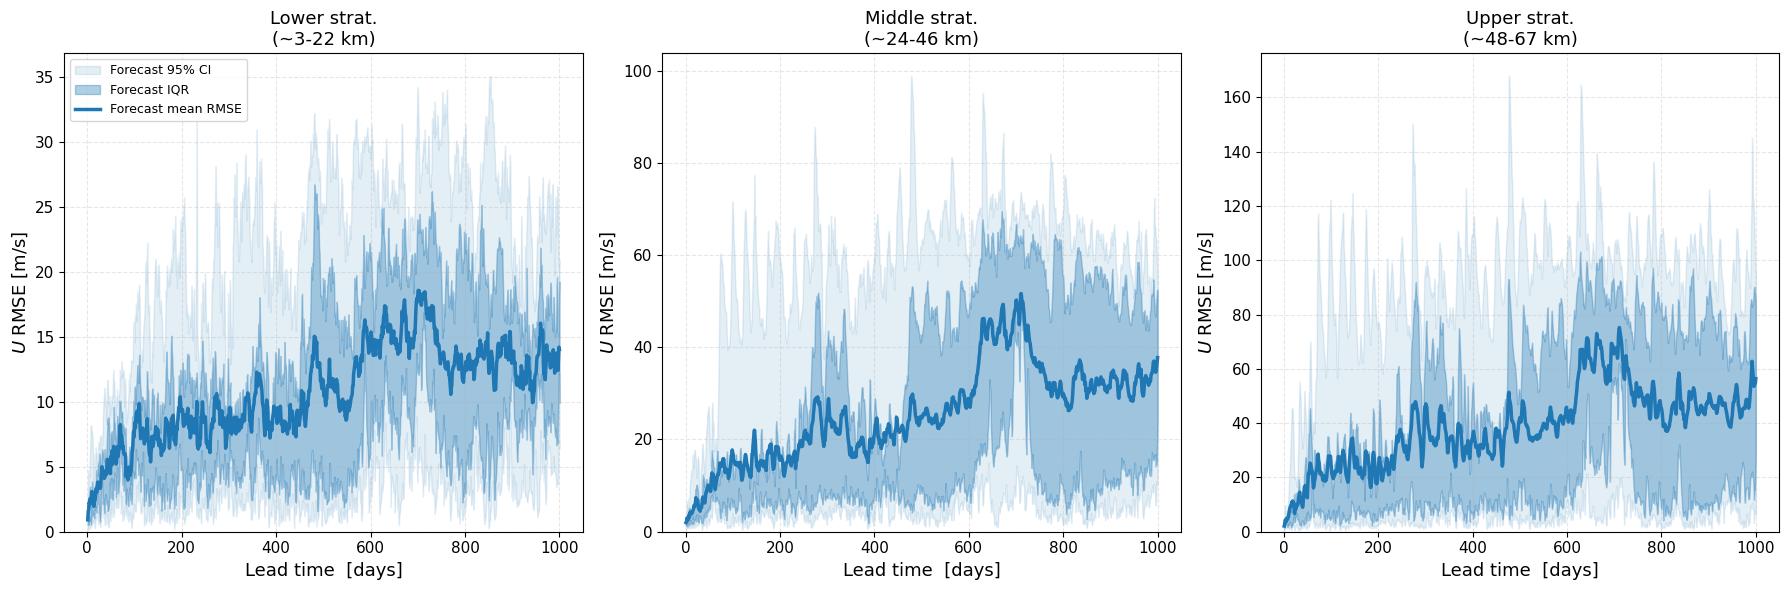

In [15]:
time_days = np.arange(1, NUM_FORECAST_DAYS + 1)

fig, axes = plt.subplots(1, len(ALT_RANGES), figsize=(6 * len(ALT_RANGES), 6), sharey=False)

for panel_i, (ax, (name, sl)) in enumerate(zip(axes, ALT_RANGES)):
    fc = all_fc_rmse[name]

    fc_mean = np.mean(fc, axis=0)
    fc_q25  = np.percentile(fc, 25,  axis=0)
    fc_q75  = np.percentile(fc, 75,  axis=0)
    fc_p025 = np.percentile(fc,  2.5, axis=0)
    fc_p975 = np.percentile(fc, 97.5, axis=0)

    ax.fill_between(time_days, fc_p025, fc_p975,
                    color='tab:blue', alpha=0.12, label='Forecast 95% CI')
    ax.fill_between(time_days, fc_q25, fc_q75,
                    color='tab:blue', alpha=0.35, label='Forecast IQR')
    ax.plot(time_days, fc_mean, color='tab:blue', linewidth=2.5,
            label='Forecast mean RMSE')

    for clim_label, clim_color, clim_ls in clim_plot_styles:
        ax.axhline(clim_rmse[clim_label][name], color=clim_color, linewidth=2,
                   linestyle=clim_ls, label=f'{clim_label} RMSE')

    ax.set_xlabel(r'Lead time  [days]', fontsize=13)
    ax.set_ylabel(r'$U$ RMSE [m/s]', fontsize=13)
    ax.set_title(name, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)
    if panel_i == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
savepath = os.path.join(SAVE_DIR, 'rmse_forecast_multipanel.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight', pad_inches=0.2)
print(f"Saved -> {savepath}")
plt.show()